In [14]:
import os
import copy
import json
import time
from pathlib import Path
#import yaml
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import sys
sys.path.append("../src")

from Models.model import GLSTMBatch
from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import create_sliding_windows, train_split, create_batchs
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     haversine_km,
                                     tensor_data_precip
                                     )     
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss

from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import eval_with_loader, train_batched_only


device = "cuda" if torch.cuda.is_available() else "cpu"

RUN_MODE = "full"  # quick or full
if RUN_MODE == "full":
    start_date = "2000-01-01"
    end_date = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date = "2025-12-31"


criterion_km = 120
num_workers = 0
catalog_dir = Path("..") / "Datasets" / "dados_inmet"
print(catalog_dir)
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)
N = len(estacoes_RS)
edge_index_knn, pos_knn = knn_topology(estacoes_RS, k=6)
edge_index_dis, edge_weights_dis, pos_dis = distance_graph(estacoes_RS, criterion_km)

..\Datasets\dados_inmet


# Extração do dataset do ERA-5





Features de entrada:
 - Precipitação diária (1980-2025)
 - velocidade vertical do vento (2006-2025)
 - Temperatura e Ponto de orvalho (2005-2025)
 - Componentes u e v do vento (2014-2025)


O vetor $X$ é um vetor no formato $[dias, nós, features]$, que contem todos os dados disponíveis, sendo partido então em treino (70%), validação (20%) e teste (10%)


In [15]:
# Data loading and feature construction

#TENSOR X COM TODAS COVARIAVEIS E DADOS NO FORMATO [T,N,F]
# X[...,0]    : DADOS DE PRECIPITAÇÃO
# X[...,1]    : VARIAVEL PÉRIODICA COM PERIODO 365
# X[...,2:8]  : DADOS DE TEMPERATURA
# X[...,9:15] : DADOS DE VELOCIDADE VERTICAL
# X[...,16,31]: DADOS DE WIND


rea_tp = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_precipitation_80-26.nc"))
rea_vv = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "vv_94-25.nc")).sel(time=slice(start_date, None))
rea_temp = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "temp_99-25.nc"))
#rea_wind = xr.open_dataset(r"C:\CLimate Change Project\Utils\wind_data\era5_wind_14-25.nc")



vv_dataset = daily_vertical_velocity(rea_vv, var_name="w")
temp_dataset = daily_temp_features(rea_temp)
#wind_daily = daily_wind_uv_features(rea_wind, u_var='u', v_var='v', levels=(500, 850))

T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1


X_tp = tensor_data_precip(rea_tp, t1=start_date, t2=end_date, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_temp = get_temp(start_date, end_date, temp_dataset, stations=estacoes_RS)

X_vv = get_vv(start_date, end_date, vv_dataset, estacoes_RS)

#X_wind = get_wind_uv(start_date, end_date, wind_daily, estacoes_RS, levels=(500,850))

#X_wind = era5_uv_to_tensor(r"C:\Climate Change Project\Utils\wind_data\era5_wind_14-25.nc",
#                           estacoes_RS,
#                           start=start_date,
#                           end=end_date,
#                           u_var="u",
#                           v_var="v"
#                           ).reshape(X_tp.shape[0], X
# _tp.shape[1], -1)


X = torch.cat([X_tp, X_temp, X_vv], dim=-1)

c:\Local Reposity\LSTM-GNN-temp\Notebooks\../src\Data\feature_extraction.py:401: FutureWarning: updating coordinate 'datetime', which is a PandasMultiIndex, would leave the multi-index level coordinates ['time', 'step'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['datetime', 'time', 'step'])` to drop the coordinates' values before assigning new coordinate values.
  tp = tp.assign_coords(datetime=tp.valid_time.data)


# Criação de janelas de tempo

O tensor X é transformado em dois vetores, $X_s$ e $y_s$ (inputs e targets), de forma que: 

 - $X_s$: $[B, W_{in}, N, F]$
 - $y_s$: $[B, W_{out}, N]$
 - $B$> : número de janelas de tempo criadas, com $W_{in}$ dias de input para prever os próximos $W_{out}$ dias
 - $N$  : Número de nós (estações)
 - $F$  : Quantidade de features de entrada por nó



In [ ]:
#CRIAÇÃO DE JANELAS DE TEMPO
eps = 1e-6
window_size = 30
horizon     = 5

Xs, ys = create_sliding_windows(X, X[...,0], window_size=window_size, horizon=horizon)

X_train, y_train, X_val, y_val, X_test, y_test = train_split(Xs, ys)


target_mean, target_std = fit_log1p_zscore_stats(X_train, y_train, target_col=0)

X_train[..., 0] = apply_log1p_zscore(X_train[..., 0], target_mean, target_std)
X_val[..., 0] = apply_log1p_zscore(X_val[..., 0], target_mean, target_std)
X_test[..., 0] = apply_log1p_zscore(X_test[..., 0], target_mean, target_std)

y_train = apply_log1p_zscore(y_train, target_mean, target_std)
y_val = apply_log1p_zscore(y_val, target_mean, target_std)
y_test = apply_log1p_zscore(y_test, target_mean, target_std)



# padroniza apenas features exogenas (colunas 2:)
X_train[..., 2:], scalers = normalize_features(X_train[..., 2:], scaler=StandardScaler)

for i, sc in enumerate(scalers):
    X_val[..., 2 + i] = torch.tensor(
        sc.transform(X_val[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_val[..., 2 + i].shape)
    X_test[..., 2 + i] = torch.tensor(
        sc.transform(X_test[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_test[..., 2 + i].shape)

normalization_stats = {
    "target_mean": float(target_mean),
    "target_std": float(target_std),
}
print("normalization_stats:", normalization_stats)


# Train/val split and DataLoaders
batch_size = 64
train_loader, val_loader, test_loader = create_batchs(X_train, X_val, X_test, y_train, y_val, y_test, batch_size, device=device, num_workers=num_workers)
print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))

normalization_stats: {'target_mean': 0.8936944007873535, 'target_std': 1.1384943723678589}
train batches: 104 val batches: 30 test batches: 15


# Treino da rede


In [17]:
edge_index = edge_index_dis.to(device)

loss_fn = nn.MSELoss()

for lr in [1e-2, 1e-3, 1e-4]:
    for hidden_dim in [32,64,128]:
        print(f"========================HIDDEN_DIM: {hidden_dim}=============================")

        model = GLSTMBatch(N=N, edge_index=edge_index, in_channels=X_train.shape[-1], hidden_size=hidden_dim,
                            out_channels=horizon, lstm_layers=1, learn_adj=True)

        model.apply(reset_weights)        
        window_folder = os.path.join("..", "Experiments", "seminar_test_glstm", f"WINDOW_{window_size}_HORIZON_{horizon}")

        exp_path = create_next_experiment_folder(window_folder)


        TEST_ITER = 1
        for j in range(TEST_ITER):
            print(f"========================ITERATION {j}=============================")
            model.apply(reset_weights)
            model, hist, summary = train_batched_only(
                model, train_loader, val_loader, hidden_dim=hidden_dim, train_period=window_size,
                epochs=150, lr=lr, weight_decay=5e-4, patience=35,run_dir=os.path.join(exp_path, f"BATCH_TEST_{j}")
            )

========================HIDDEN_DIM: 32=============================
========================ITERATION 0=============================
train_batched_only: use_amp=False
epoch=1/150train_loss=9.879159e-01/val_loss=8.592223e-01/train_mae=8.266913e-01/val_mae=7.721213e-01/val_mape=1.201383e+02/val_r2=6.726031e-03
epoch=2/150train_loss=9.483688e-01/val_loss=8.521402e-01/train_mae=8.052772e-01/val_mae=7.665015e-01/val_mape=1.176276e+02/val_r2=1.540424e-02
epoch=3/150train_loss=9.429081e-01/val_loss=8.536097e-01/train_mae=8.018306e-01/val_mae=7.712206e-01/val_mape=1.187155e+02/val_r2=1.201031e-02
epoch=4/150train_loss=9.393061e-01/val_loss=8.515396e-01/train_mae=8.002293e-01/val_mae=7.689428e-01/val_mape=1.195636e+02/val_r2=1.427449e-02
epoch=5/150train_loss=9.372613e-01/val_loss=8.476870e-01/train_mae=7.990932e-01/val_mae=7.615932e-01/val_mape=1.188619e+02/val_r2=1.972257e-02
epoch=6/150train_loss=9.374879e-01/val_loss=8.484963e-01/train_mae=7.992249e-01/val_mae=7.649155e-01/val_mape=1.194052

# Post Train analysis


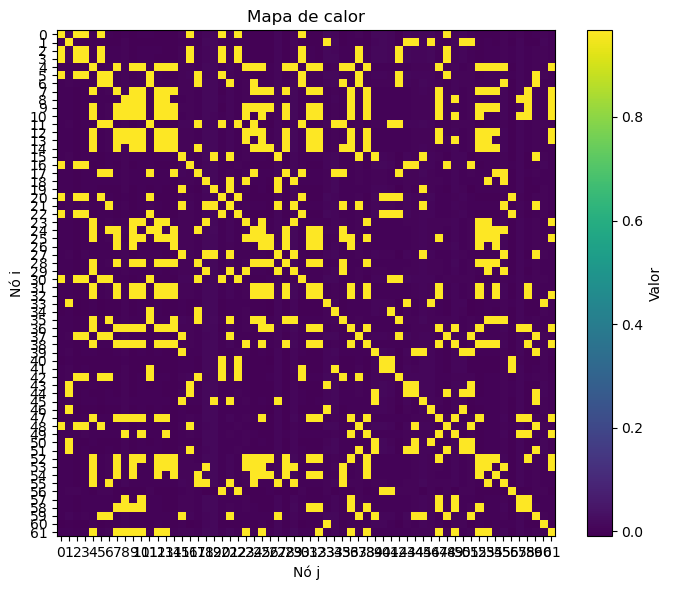

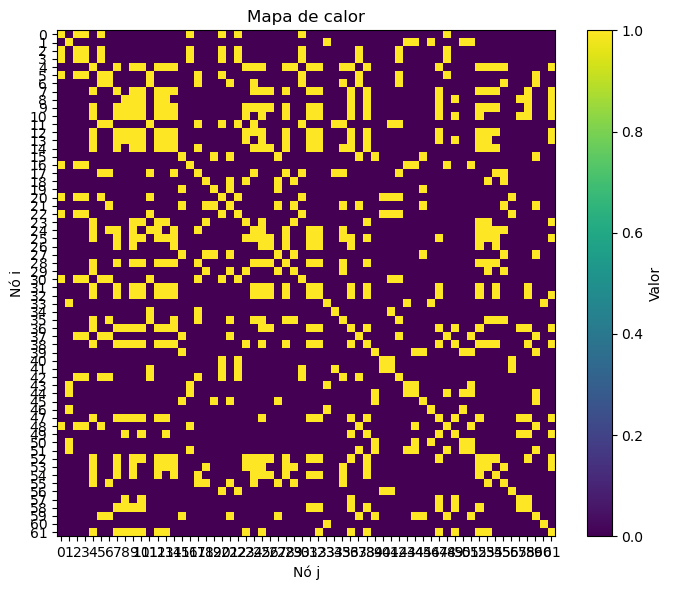

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Mapa de calor'}, xlabel='Nó j', ylabel='Nó i'>)

In [5]:
plot_heatmap_nn(model.cell_0.A)
plot_heatmap_nn(adjacency_matrix(N, edge_index_dis))